## Imports y geometría base

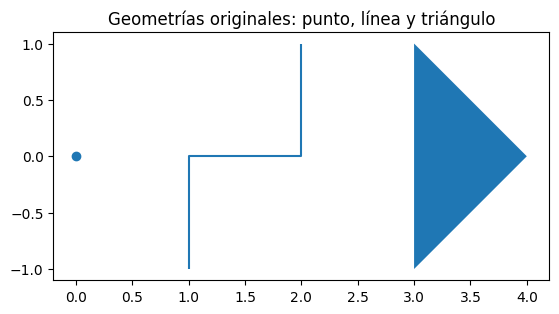

In [1]:
import geopandas
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon

# Creamos 3 tipos de geometría distintos en una sola GeoSeries
s = geopandas.GeoSeries([
    Point(0, 0),
    LineString([(1, -1), (1, 0), (2, 0), (2, 1)]),
    Polygon([(3, -1), (4, 0), (3, 1)]),
])

s.plot()
plt.title('Geometrías originales: punto, línea y triángulo')
plt.show()

## Métodos constructivos

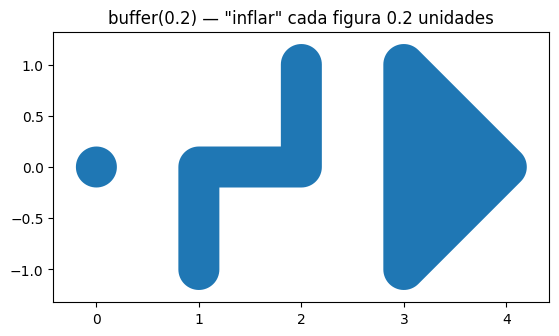

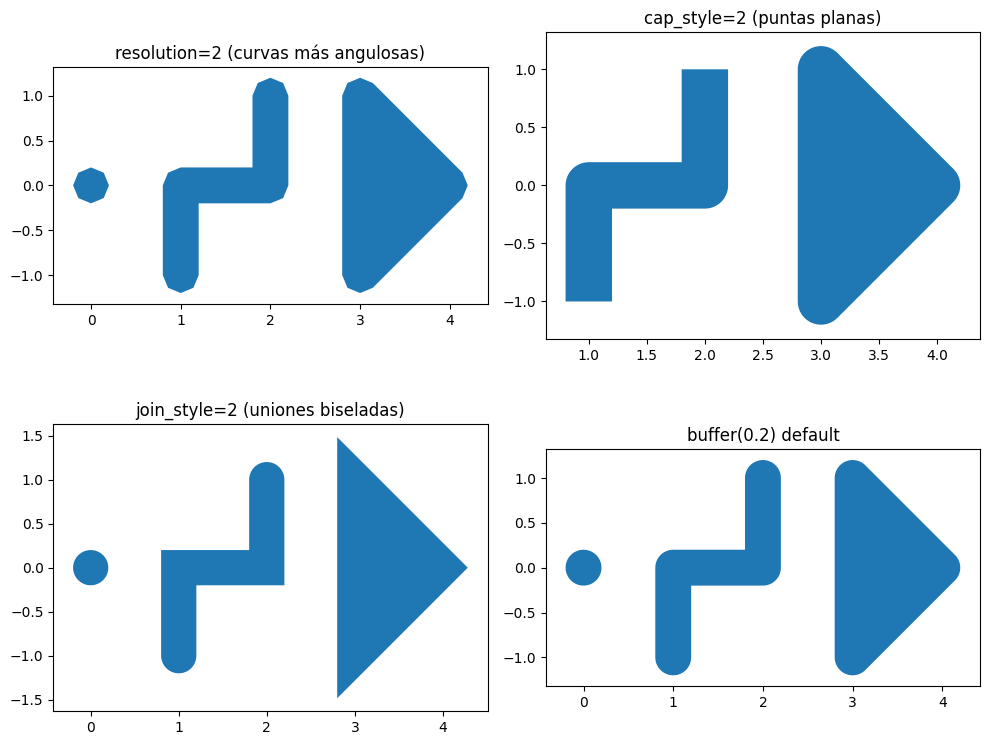

0             GEOMETRYCOLLECTION EMPTY
1           MULTIPOINT ((1 -1), (2 1))
2    LINESTRING (3 -1, 4 0, 3 1, 3 -1)
dtype: geometry


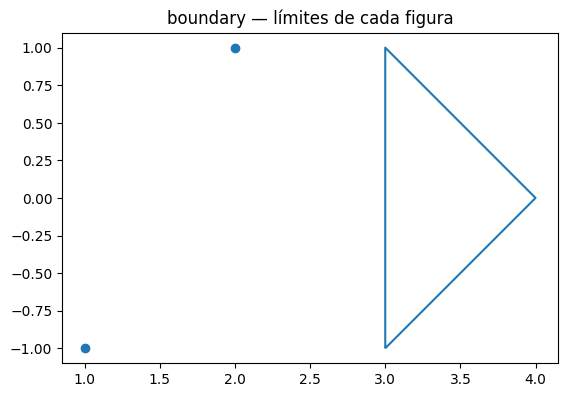

0          POINT (0 0)
1        POINT (1.5 0)
2    POINT (3.33333 0)
dtype: geometry


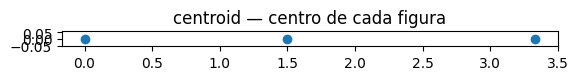

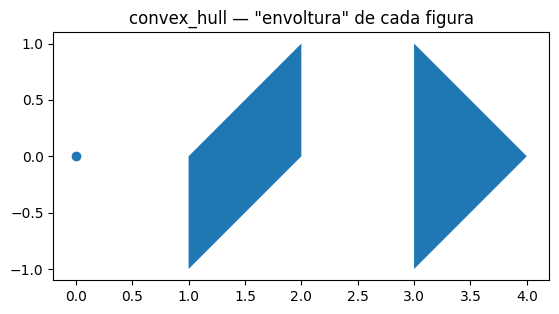

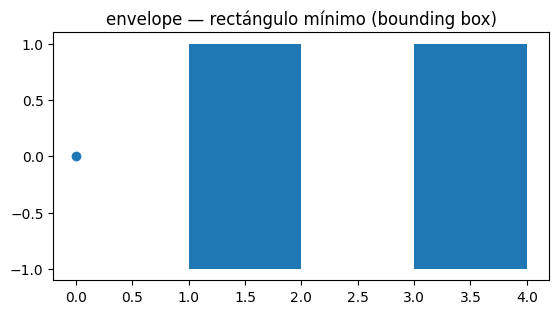

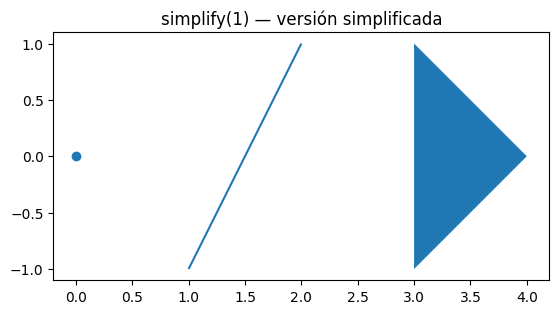

GEOMETRYCOLLECTION (POINT (0 0), LINESTRING (1 -1, 1 0, 2 0, 2 1), POLYGON ((3 -1, 4 0, 3 1, 3 -1)))


In [3]:
# --- BUFFER: genera un área alrededor de cada geometría ---
s.buffer(0.2).plot()
plt.title('buffer(0.2) — "inflar" cada figura 0.2 unidades')
plt.show()

# Variantes con distintos estilos de punta/unión
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
s.buffer(0.2, resolution=2).plot(ax=axes[0,0])
axes[0,0].set_title('resolution=2 (curvas más angulosas)')

s.buffer(0.2, cap_style=2).plot(ax=axes[0,1])
axes[0,1].set_title('cap_style=2 (puntas planas)')

s.buffer(0.2, join_style=2).plot(ax=axes[1,0])
axes[1,0].set_title('join_style=2 (uniones biseladas)')

s.buffer(0.2).plot(ax=axes[1,1])
axes[1,1].set_title('buffer(0.2) default')
plt.tight_layout()
plt.show()

# --- BOUNDARY: el límite/contorno de cada geometría ---
print(s.boundary)
s.boundary.plot()
plt.title('boundary — límites de cada figura')
plt.show()

# --- CENTROID: el centro geométrico de cada figura ---
print(s.centroid)
s.centroid.plot()
plt.title('centroid — centro de cada figura')
plt.show()

# --- CONVEX_HULL: el polígono convexo mínimo que envuelve cada figura ---
s.convex_hull.plot()
plt.title('convex_hull — "envoltura" de cada figura')
plt.show()

# --- ENVELOPE: el rectángulo mínimo que contiene cada figura ---
s.envelope.plot()
plt.title('envelope — rectángulo mínimo (bounding box)')
plt.show()

# --- SIMPLIFY: reduce vértices manteniendo la forma general ---
s.simplify(1).plot()
plt.title('simplify(1) — versión simplificada')
plt.show()

# --- UNARY_UNION (o union_all en versiones nuevas): combina todo en una sola geometría ---
# print(s.unary_union)
# Alternativa recomendada en GeoPandas reciente:
print(s.union_all())

## Transformaciones (rotate, scale, skew, translate)

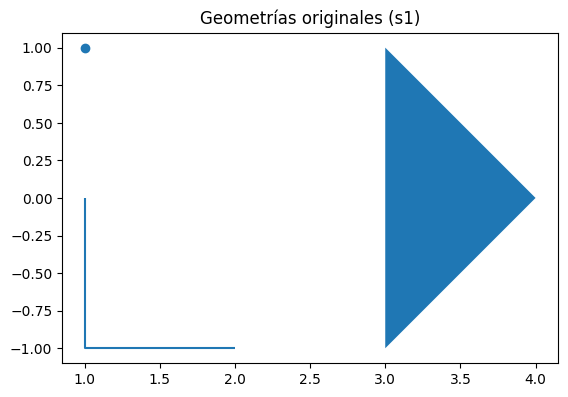

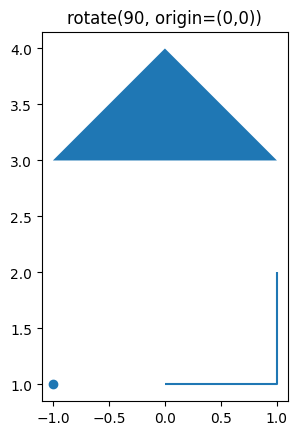

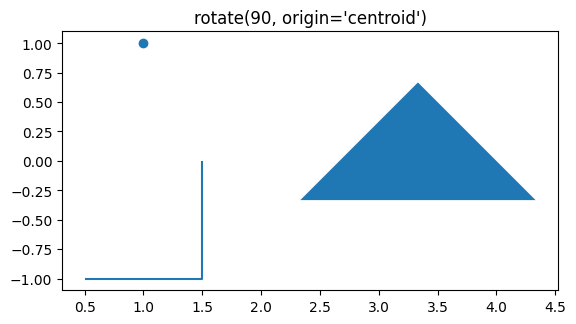

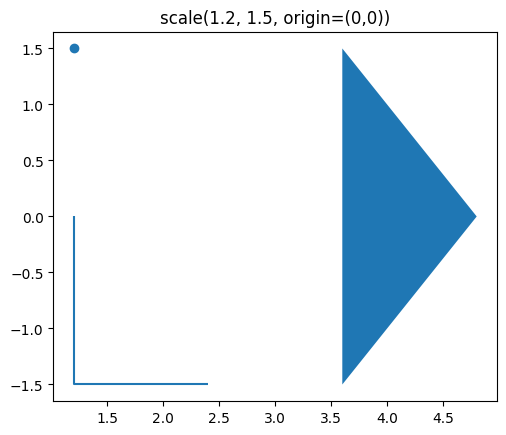

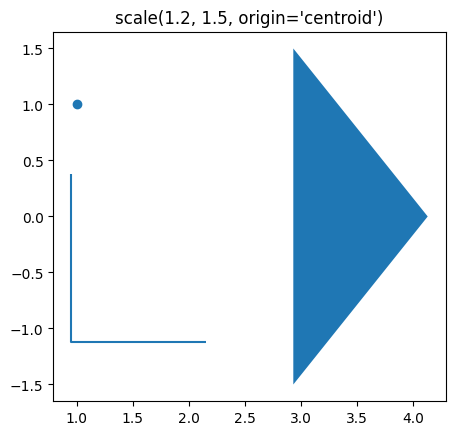

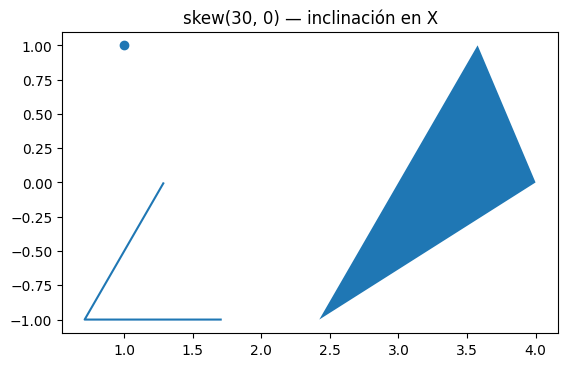

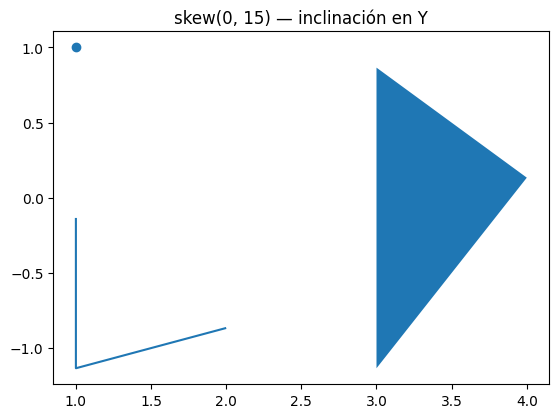

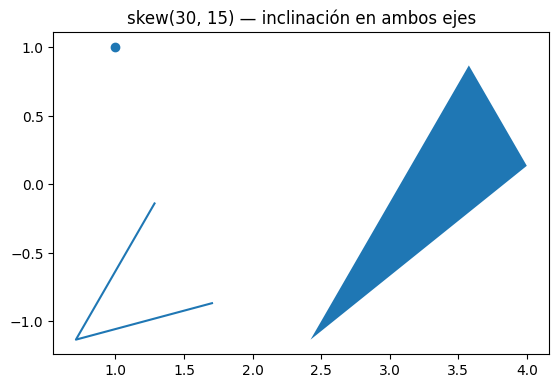

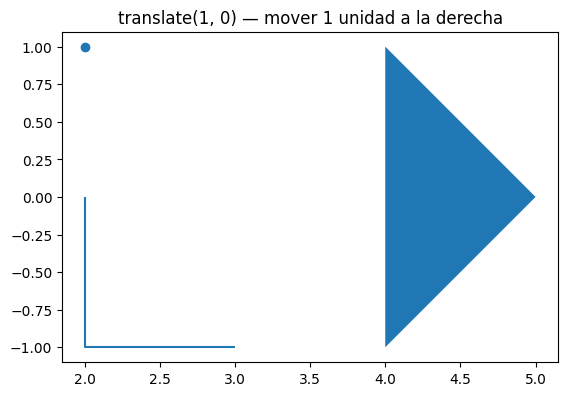

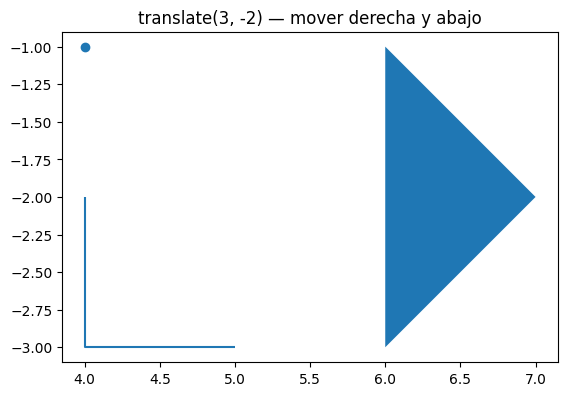

In [4]:
# Nueva GeoSeries de ejemplo para esta sección
s1 = geopandas.GeoSeries([
    Point(1, 1),
    LineString([(2, -1), (1, -1), (1, 0)]),
    Polygon([(3, -1), (4, 0), (3, 1)]),
])

s1.plot()
plt.title('Geometrías originales (s1)')
plt.show()

# --- ROTATE: girar cada geometría ---
# Rotando 90° con respecto al origen (0,0) -> las figuras se ALEJAN mucho del origen
s1.rotate(90, origin=(0,0)).plot()
plt.title('rotate(90, origin=(0,0))')
plt.show()

# Rotando 90° con respecto al centroide de cada figura -> giran "en su lugar"
s1.rotate(90, origin='centroid').plot()
plt.title("rotate(90, origin='centroid')")
plt.show()

# --- SCALE: agrandar/encoger cada geometría ---
s1.scale(1.2, 1.5, origin=(0,0)).plot()
plt.title('scale(1.2, 1.5, origin=(0,0))')
plt.show()

s1.scale(1.2, 1.5, origin='centroid').plot()
plt.title("scale(1.2, 1.5, origin='centroid')")
plt.show()

# --- SKEW: inclinar/distorsionar cada geometría ---
s1.skew(30, 0).plot()
plt.title('skew(30, 0) — inclinación en X')
plt.show()

s1.skew(0, 15).plot()
plt.title('skew(0, 15) — inclinación en Y')
plt.show()

s1.skew(30, 15).plot()
plt.title('skew(30, 15) — inclinación en ambos ejes')
plt.show()

# --- TRANSLATE: mover cada geometría sin cambiar su forma ---
s1.translate(1, 0).plot()
plt.title('translate(1, 0) — mover 1 unidad a la derecha')
plt.show()

s1.translate(3, -2).plot()
plt.title('translate(3, -2) — mover derecha y abajo')
plt.show()

## Comparar antes/después en un solo gráfico

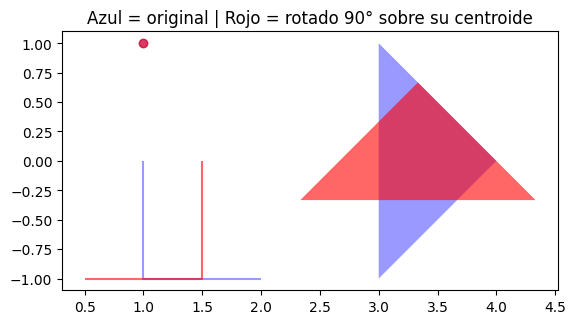

In [5]:
fig, ax = plt.subplots()

# Original en azul (con transparencia)
s1.plot(ax=ax, color='blue', alpha=0.4)

# Transformado en rojo
s1.rotate(90, origin='centroid').plot(ax=ax, color='red', alpha=0.6)

ax.set_title('Azul = original | Rojo = rotado 90° sobre su centroide')
plt.show()

# Reto

Pon en práctica las funciones revisadas, para ello te preparamos el 
siguiente ejercicio:
## 1
Utiliza el archivo Tabulado_INEGI_2010.csv que descargaste en la lección 3, si no cuentas con el puedes volverlo a descargar desde la sección de archivos adjuntos. También puedes utilizar un archivo propio que contenga información geométrica.
## 2 
Crea una nueva hoja de trabajo de Google Colab y carga tu información en un GeoDataFrame.
## 3 
Imprime la información relativa a geometrías para asegurarte de que la representación que estás haciendo es correcta.
## 4 
Aplica algunas funciones y transformaciones a tus geometrías para experimentar con ellas.

c:\Users\diego\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: 2. Mapas/mexican-states.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


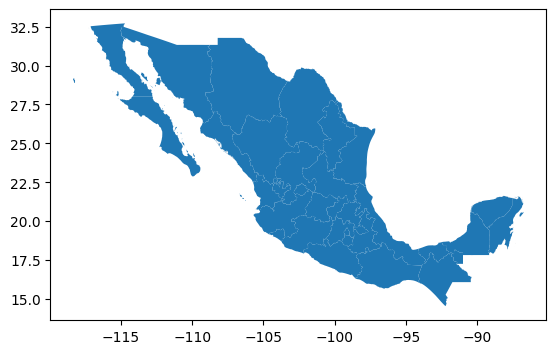

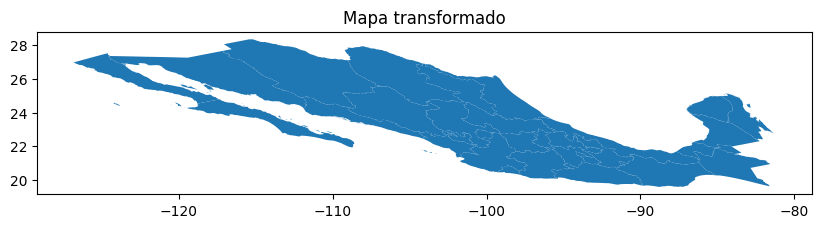

C:\Users\diego\AppData\Local\Temp\ipykernel_30204\1235463057.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  .centroid
C:\Users\diego\AppData\Local\Temp\ipykernel_30204\1235463057.py:51: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  .centroid


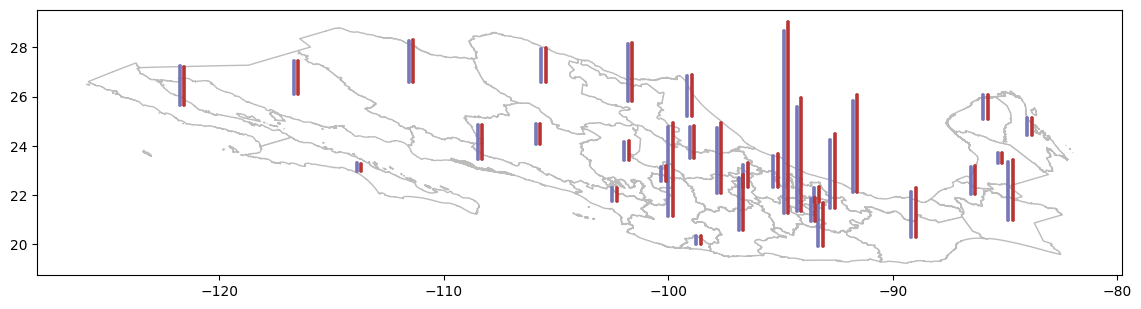

In [10]:
import geopandas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mex = geopandas.read_file('2. Mapas/mexican-states.shp' )
mex2 = mex.sort_values(by=['name'])
mex2[['name','geometry']]
columnas = ['Entidad', 'Total_2000', 'Hombres_2000', 'Mujeres_2000',
            'Total_2005', 'Hombres_2005', 'Mujeres_2005',
            'Total', 'Hombres', 'Mujeres']

Poblacion = pd.read_csv(
    '2. Mapas/Tabulado_INEGI_2010.csv',
    encoding='utf-8-sig',   # quita el BOM invisible al inicio del archivo
    skiprows=3,             # salta las 2 filas de encabezado + "Estados Unidos Mexicanos"
    header=None,
    names=columnas
)

mexgdf = mex.merge(Poblacion, left_on=['name'], right_on=['Entidad'])
mexgdf[['name', 'Entidad', 'geometry', 'Total']]
mex.plot()
#Asignamos centroides
x0=-102.57634952
y0=23.9353719
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

mex['geometry'].skew(
    xs=-40,
    ys=-10,
    use_radians=False,
    origin=(x0, y0)
).rotate(
    angle=20,
    use_radians=False,
    origin=(x0, y0)
).plot(ax=ax)

ax.set_title('Mapa transformado')
plt.show()
plt.show()
mex_tr = (mex['geometry']          
    .skew(xs=-40,ys=0,use_radians=False,origin=(x0,y0))
    .rotate(angle=15,use_radians=False,origin=(x0,y0)))
x=(mex_tr
  .centroid
  .apply(lambda p:p.x)
  .values)
y=(mex_tr
  .centroid
  .apply(lambda p:p.y)
  .values)
fig,ax = plt.subplots(1,1,figsize=(14,14))
#Graficamos el mapa
mex_tr.plot(ax=ax,
           color='#ffffff',
           edgecolor='#bcbcbc',
           zorder=1)
#Graficamos numero de Hombres en cada estado (en millones)
for i in range(32):
  ax.plot([x,x],
  [y,y+(mexgdf['Hombres'].values/1000000)],
  color='#7777bb',
  zorder=1)
#Graficamos numero de Mujeres en cada estado (en millones)
for i in range(32):
  ax.plot([x+0.2,x+0.2],
  [y,y+(mexgdf['Mujeres'].values/1000000)],
  color='#bb3333',
  zorder=1)
plt.show()